# 🌡️ Exploration des données climatiques — Open-Meteo
**Défi data.gouv.fr — Changement Climatique**  
Villes : **Bordeaux (33)** | **Rennes (35)** | **Nantes (44)** | **Paris (75)**  
Période : 2000–2023 | Source : Open-Meteo Archive API (ERA5)

---
### Sommaire
1. [Chargement & aperçu](#1)
2. [Qualité des données](#2)
3. [Statistiques descriptives](#3)
4. [Distributions](#4)
5. [Cycle saisonnier](#5)
6. [Évolution temporelle & tendances](#6)
7. [Anomalies climatiques](#7)
8. [Événements extrêmes](#8)
9. [Corrélations entre variables](#9)
10. [Comparaison inter-villes](#10)
11. [Synthèse](#11)

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})

COLORS = {'Bordeaux':'#E07B39','Rennes':'#3A86FF','Nantes':'#2EC4B6','Paris':'#FF006E'}
VILLES = list(COLORS.keys())
MOIS_FR = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
SAISONS = {12:'Hiver',1:'Hiver',2:'Hiver',3:'Printemps',4:'Printemps',5:'Printemps',
           6:'Été',7:'Été',8:'Été',9:'Automne',10:'Automne',11:'Automne'}
print('✓ Imports OK')

✓ Imports OK


---
## 1. Chargement & aperçu <a id='1'></a>

In [2]:
df = pd.read_csv('data_climat/observations_quotidiennes.csv', sep=';', parse_dates=['DATE'])
df = df.sort_values(['ville','DATE']).reset_index(drop=True)
df['ANNEE']  = df['DATE'].dt.year
df['MOIS']   = df['DATE'].dt.month
df['SAISON'] = df['MOIS'].map(SAISONS)

print(f'Dimensions   : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Période      : {df.DATE.min().date()} -> {df.DATE.max().date()}')
print(f'Villes       : {sorted(df.ville.unique())}')
print(f'Lignes/ville : {df.groupby("ville").size().to_dict()}')
df.head(6)

Dimensions   : 35,064 lignes x 23 colonnes
Période      : 2000-01-01 -> 2023-12-31
Villes       : ['Bordeaux', 'Nantes', 'Paris', 'Rennes']
Lignes/ville : {'Bordeaux': 8766, 'Nantes': 8766, 'Paris': 8766, 'Rennes': 8766}


,DATE,TX,TN,TM,RR,RR_pluie,neige_cm,heures_precip,vent_max_kmh,rafales_max_kmh,...,code_meteo,ville,departement,latitude,longitude,ensoleillement_h,duree_jour_h,ANNEE,MOIS,SAISON
0,2000-01-01,11.3,7.6,9.0,0.3,0.3,0.0,2.0,5.4,11.2,...,51,Bordeaux,33,44.8333,-0.5667,2.74,8.85,2000,1,Hiver
1,2000-01-02,9.1,6.1,7.5,0.0,0.0,0.0,0.0,7.0,13.3,...,3,Bordeaux,33,44.8333,-0.5667,0.00,8.87,2000,1,Hiver
2,2000-01-03,11.5,4.4,7.1,0.0,0.0,0.0,0.0,8.7,18.7,...,3,Bordeaux,33,44.8333,-0.5667,8.10,8.88,2000,1,Hiver
3,2000-01-04,11.7,2.6,6.9,0.0,0.0,0.0,0.0,10.2,22.0,...,3,Bordeaux,33,44.8333,-0.5667,5.27,8.90,2000,1,Hiver
4,2000-01-05,13.1,6.6,9.6,0.0,0.0,0.0,0.0,10.0,21.6,...,3,Bordeaux,33,44.8333,-0.5667,7.26,8.92,2000,1,Hiver
5,2000-01-06,12.3,4.2,7.5,0.0,0.0,0.0,0.0,10.4,21.2,...,3,Bordeaux,33,44.8333,-0.5667,8.00,8.94,2000,1,Hiver


In [3]:
vars_clim = ['TX','TN','TM','RR','vent_max_kmh','rafales_max_kmh',
             'rayonnement_MJ','ensoleillement_h','evapotranspiration']
df[vars_clim].describe().round(2)

,TX,TN,TM,RR,vent_max_kmh,rafales_max_kmh,rayonnement_MJ,ensoleillement_h,evapotranspiration
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,16.70,8.80,12.66,2.03,18.19,37.09,12.55,8.45,2.31
std,6.98,5.65,6.14,4.04,6.98,13.85,7.81,4.43,1.59
min,-3.40,-10.20,-5.70,0.00,4.60,9.70,0.23,0.00,0.12
25%,11.50,4.80,8.30,0.00,13.00,27.40,5.55,5.38,0.92
50%,16.40,9.10,12.60,0.10,17.00,34.90,11.58,8.96,2.00
75%,21.70,13.20,17.30,2.20,22.10,44.30,18.79,12.00,3.40
max,40.70,25.00,32.20,66.90,59.00,124.20,30.65,15.87,9.99


---
## 2. Qualité des données <a id='2'></a>

In [4]:
missing = pd.DataFrame({
    'Manquantes': df[vars_clim].isna().sum(),
    'Taux (%)':   (df[vars_clim].isna().mean()*100).round(3),
}).sort_values('Taux (%)', ascending=False)
print('=== VALEURS MANQUANTES ==='); print(missing)

incoherent = df[(df['TN'] > df['TM']) | (df['TM'] > df['TX'])]
print(f'\nIncoherences TN/TM/TX : {len(incoherent)} lignes ({len(incoherent)/len(df)*100:.2f}%)')

=== VALEURS MANQUANTES ===
                    Manquantes  Taux (%)
TX                           0       0.0
TN                           0       0.0
TM                           0       0.0
RR                           0       0.0
vent_max_kmh                 0       0.0
rafales_max_kmh              0       0.0
rayonnement_MJ               0       0.0
ensoleillement_h             0       0.0
evapotranspiration           0       0.0

Incoherences TN/TM/TX : 0 lignes (0.00%)


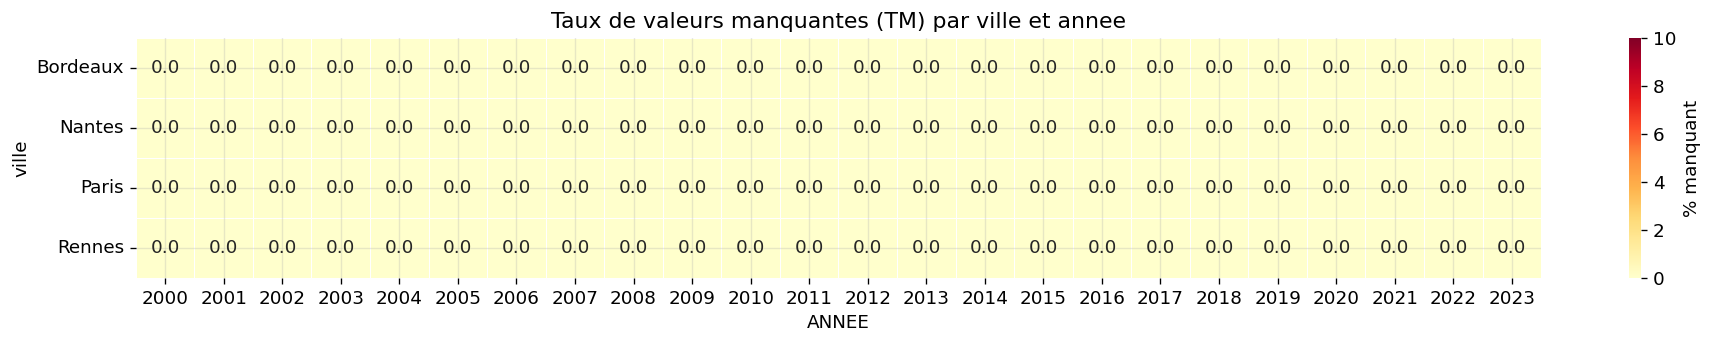

In [5]:
pivot_miss = (df.groupby(['ville','ANNEE'])['TM']
              .apply(lambda x: x.isna().mean()*100).unstack('ANNEE'))
fig, ax = plt.subplots(figsize=(16,3))
sns.heatmap(pivot_miss, ax=ax, cmap='YlOrRd', vmin=0, vmax=10,
            annot=True, fmt='.1f', linewidths=0.3, cbar_kws={'label':'% manquant'})
ax.set_title('Taux de valeurs manquantes (TM) par ville et annee')
plt.tight_layout(); plt.show()

---
## 3. Statistiques descriptives <a id='3'></a>

In [6]:
stats_ville = df.groupby('ville')[vars_clim].agg(['mean','std','min','max']).round(2)
print('=== STATISTIQUES PAR VILLE ==='); stats_ville

=== STATISTIQUES PAR VILLE ===


TX                     TN                       TM        ...  \
           mean   std  min   max  mean   std   min   max   mean   std  ...   
ville                                                                  ...   
Bordeaux  18.58  7.33 -2.4  40.5  9.75  5.86  -8.2  25.0  13.97  6.41  ...   
Nantes    16.46  6.53 -2.0  40.1  9.19  5.38  -7.0  24.4  12.72  5.79  ...   
Paris     15.87  7.31 -3.4  40.7  7.95  5.91 -10.2  23.3  11.91  6.50  ...   
Rennes    15.90  6.36 -1.7  39.7  8.30  5.22  -7.5  24.0  12.02  5.61  ...   

         rayonnement_MJ        ensoleillement_h                    \
                    min    max             mean   std  min    max   
ville                                                               
Bordeaux           0.50  30.65             9.03  4.08  0.0  15.09   
Nantes             0.27  30.48             8.59  4.40  0.0  15.63   
Paris              0.23  30.01             7.87  4.66  0.0  15.87   
Rennes             0.30  30.29             8.31  4.47  0.0  15.75   

         evapotranspiration                    
                       mean   std   min   max  
ville                                          
Bordeaux               2.56  1.68  0.15  9.06  
Nantes                 2.31  1.58  0.15  9.99  
Paris                  2.20  1.57  0.12  9.15  
Rennes                 2.16  1.48  0.14  9.64  

[4 rows x 36 columns]

In [7]:
clim_mois = df.groupby(['ville','MOIS'])[['TX','TN','TM','RR','ensoleillement_h']].mean().round(2).reset_index()
clim_mois['MOIS_NOM'] = clim_mois['MOIS'].apply(lambda m: MOIS_FR[m-1])
print('=== CLIMATOLOGIE MENSUELLE — PARIS ==='); clim_mois[clim_mois['ville']=='Paris']

=== CLIMATOLOGIE MENSUELLE — PARIS ===


,ville,MOIS,TX,TN,TM,RR,ensoleillement_h,MOIS_NOM
24,Paris,1,7.06,1.84,4.42,1.75,3.72,Jan
25,Paris,2,8.61,1.82,5.07,1.66,5.50,Fév
26,Paris,3,11.90,3.39,7.53,1.84,7.44,Mar
27,Paris,4,15.47,5.80,10.72,1.57,9.90,Avr
28,Paris,5,18.81,9.58,14.34,2.10,10.60,Mai
29,Paris,6,22.61,13.20,18.10,2.02,11.54,Jun
30,Paris,7,24.47,15.05,19.91,1.91,11.41,Jul
31,Paris,8,24.35,14.83,19.64,1.95,10.66,Aoû
32,Paris,9,21.28,12.14,16.64,1.41,8.86,Sep
33,Paris,10,16.74,9.40,12.88,2.14,6.53,Oct


---
## 4. Distributions <a id='4'></a>

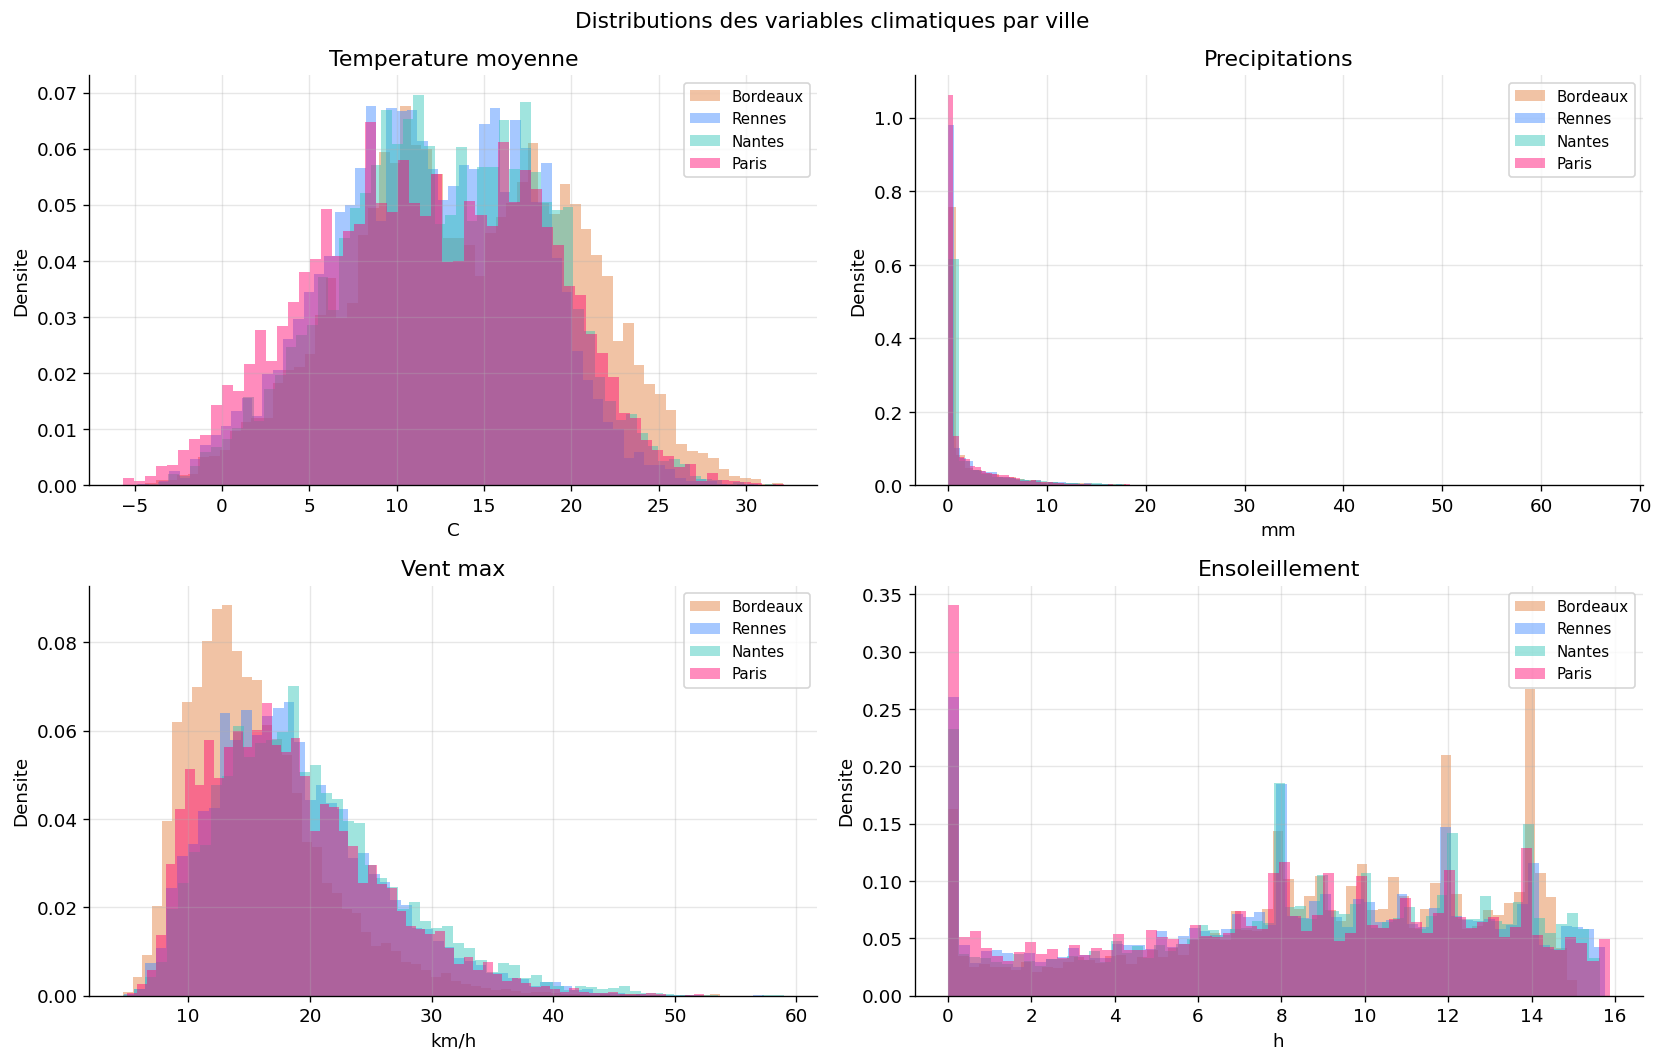

In [8]:
vars_plot = [('TM','C','Temperature moyenne'),('RR','mm','Precipitations'),
             ('vent_max_kmh','km/h','Vent max'),('ensoleillement_h','h','Ensoleillement')]
fig, axes = plt.subplots(2,2,figsize=(14,9))
for ax, (var,unit,titre) in zip(axes.flatten(), vars_plot):
    for ville in VILLES:
        d = df.loc[df['ville']==ville, var].dropna()
        ax.hist(d, bins=60, alpha=0.45, color=COLORS[ville], label=ville, density=True)
    ax.set_title(titre); ax.set_xlabel(unit); ax.set_ylabel('Densite'); ax.legend(fontsize=9)
fig.suptitle('Distributions des variables climatiques par ville', fontsize=13)
plt.tight_layout(); plt.show()

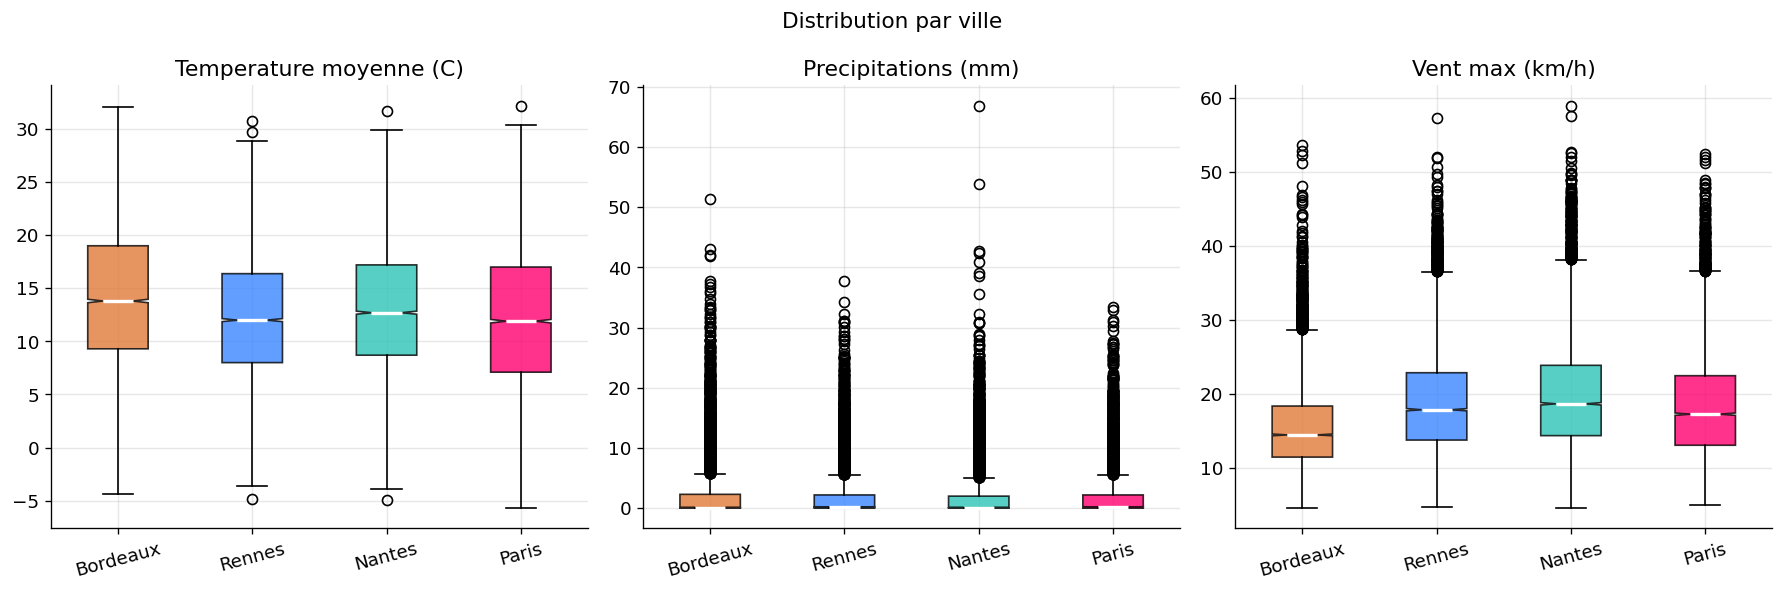

In [9]:
fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax, var, titre in zip(axes,['TM','RR','vent_max_kmh'],
                          ['Temperature moyenne (C)','Precipitations (mm)','Vent max (km/h)']):
    data = [df.loc[df['ville']==v,var].dropna().values for v in VILLES]
    bp = ax.boxplot(data, patch_artist=True, notch=True, medianprops={'color':'white','linewidth':2})
    for patch, ville in zip(bp['boxes'], VILLES):
        patch.set_facecolor(COLORS[ville]); patch.set_alpha(0.8)
    ax.set_xticklabels(VILLES, rotation=15); ax.set_title(titre)
plt.suptitle('Distribution par ville', fontsize=13)
plt.tight_layout(); plt.show()

---
## 5. Cycle saisonnier <a id='5'></a>

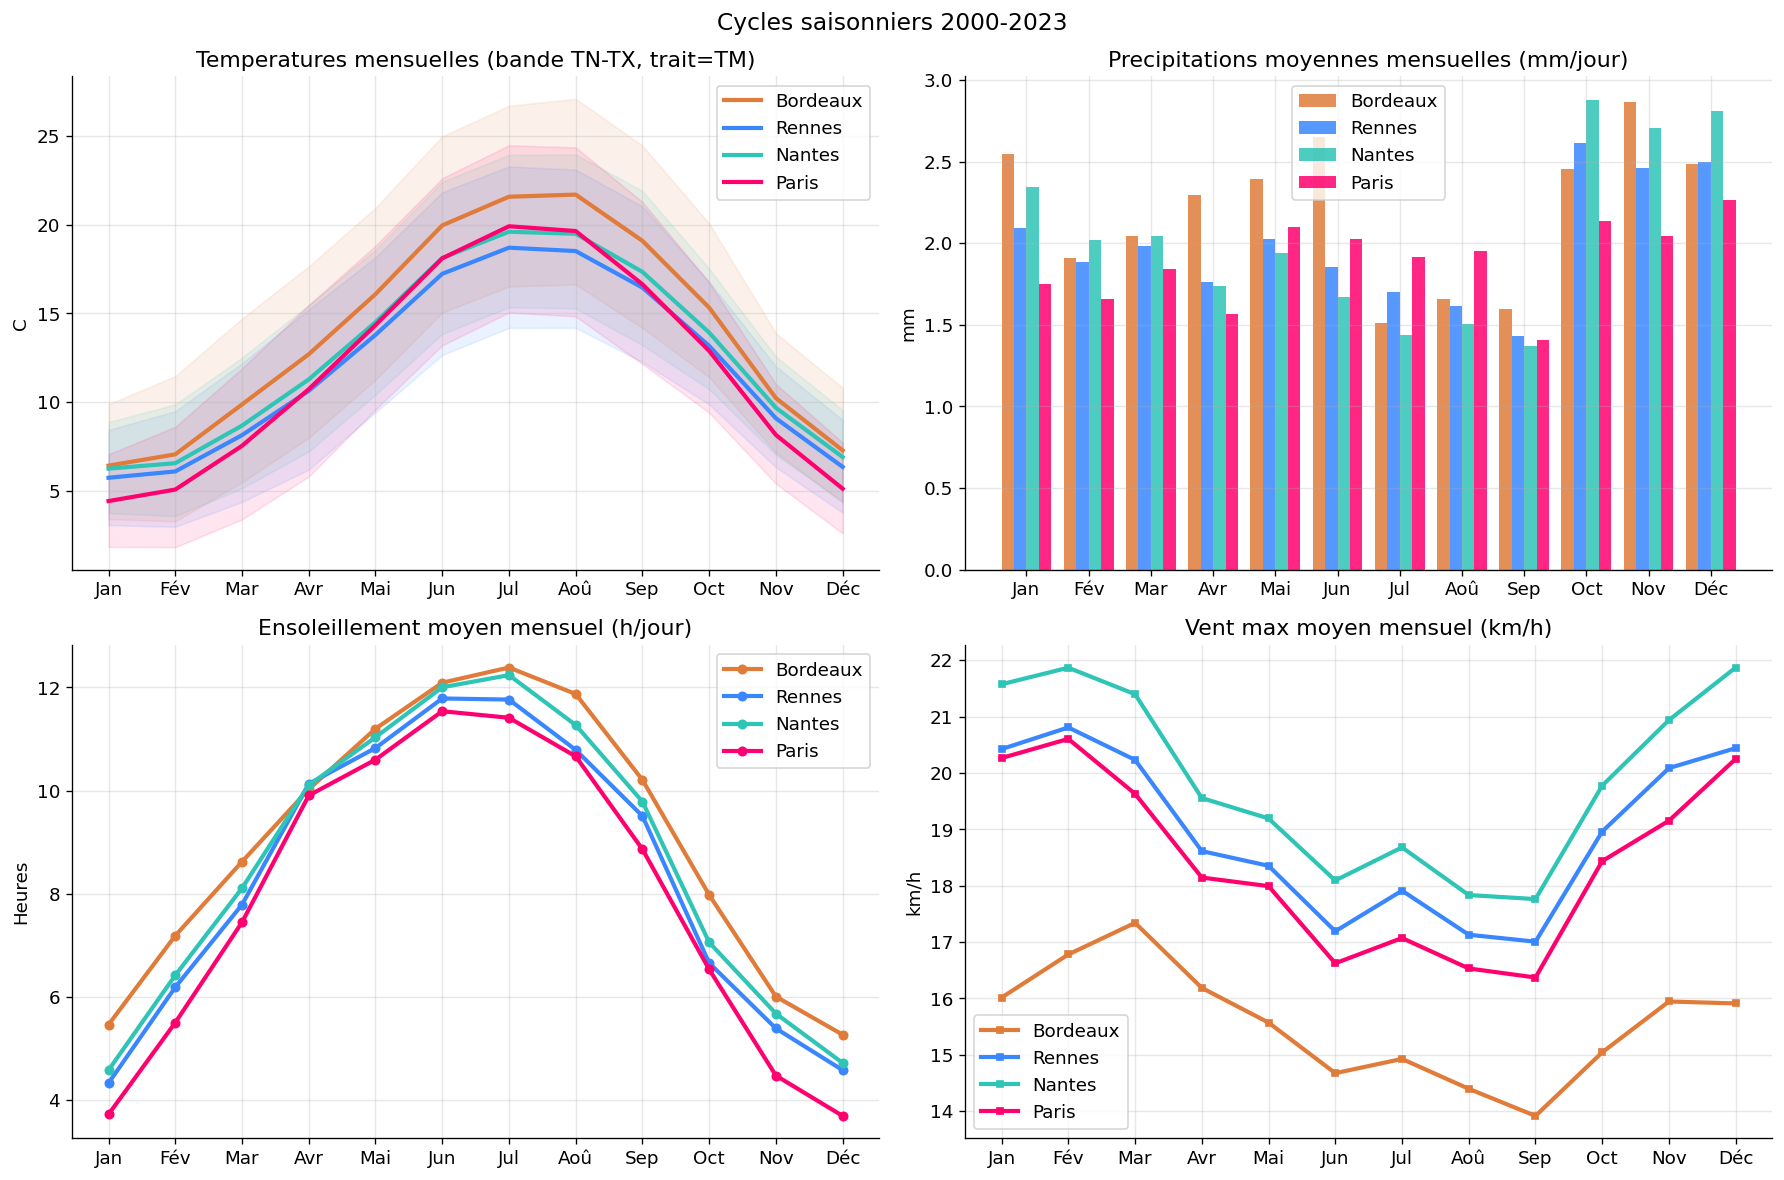

In [10]:
fig, axes = plt.subplots(2,2,figsize=(15,10))

ax = axes[0,0]
for ville in VILLES:
    sub = df[df['ville']==ville].groupby('MOIS')[['TX','TN','TM']].mean()
    ax.plot(sub.index, sub['TM'], color=COLORS[ville], lw=2.5, label=ville)
    ax.fill_between(sub.index, sub['TN'], sub['TX'], color=COLORS[ville], alpha=0.1)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MOIS_FR)
ax.set_title('Temperatures mensuelles (bande TN-TX, trait=TM)'); ax.set_ylabel('C'); ax.legend()

ax = axes[0,1]
x = np.arange(12); w = 0.2
for i, ville in enumerate(VILLES):
    sub = df[df['ville']==ville].groupby('MOIS')['RR'].mean()
    ax.bar(x+i*w, sub.values, w, color=COLORS[ville], label=ville, alpha=0.85)
ax.set_xticks(x+0.3); ax.set_xticklabels(MOIS_FR)
ax.set_title('Precipitations moyennes mensuelles (mm/jour)'); ax.set_ylabel('mm'); ax.legend()

ax = axes[1,0]
for ville in VILLES:
    sub = df[df['ville']==ville].groupby('MOIS')['ensoleillement_h'].mean()
    ax.plot(sub.index, sub.values, color=COLORS[ville], lw=2.5, marker='o', ms=5, label=ville)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MOIS_FR)
ax.set_title('Ensoleillement moyen mensuel (h/jour)'); ax.set_ylabel('Heures'); ax.legend()

ax = axes[1,1]
for ville in VILLES:
    sub = df[df['ville']==ville].groupby('MOIS')['vent_max_kmh'].mean()
    ax.plot(sub.index, sub.values, color=COLORS[ville], lw=2.5, marker='s', ms=4, label=ville)
ax.set_xticks(range(1,13)); ax.set_xticklabels(MOIS_FR)
ax.set_title('Vent max moyen mensuel (km/h)'); ax.set_ylabel('km/h'); ax.legend()

fig.suptitle('Cycles saisonniers 2000-2023', fontsize=14)
plt.tight_layout(); plt.show()

---
## 6. Evolution temporelle & tendances <a id='6'></a>

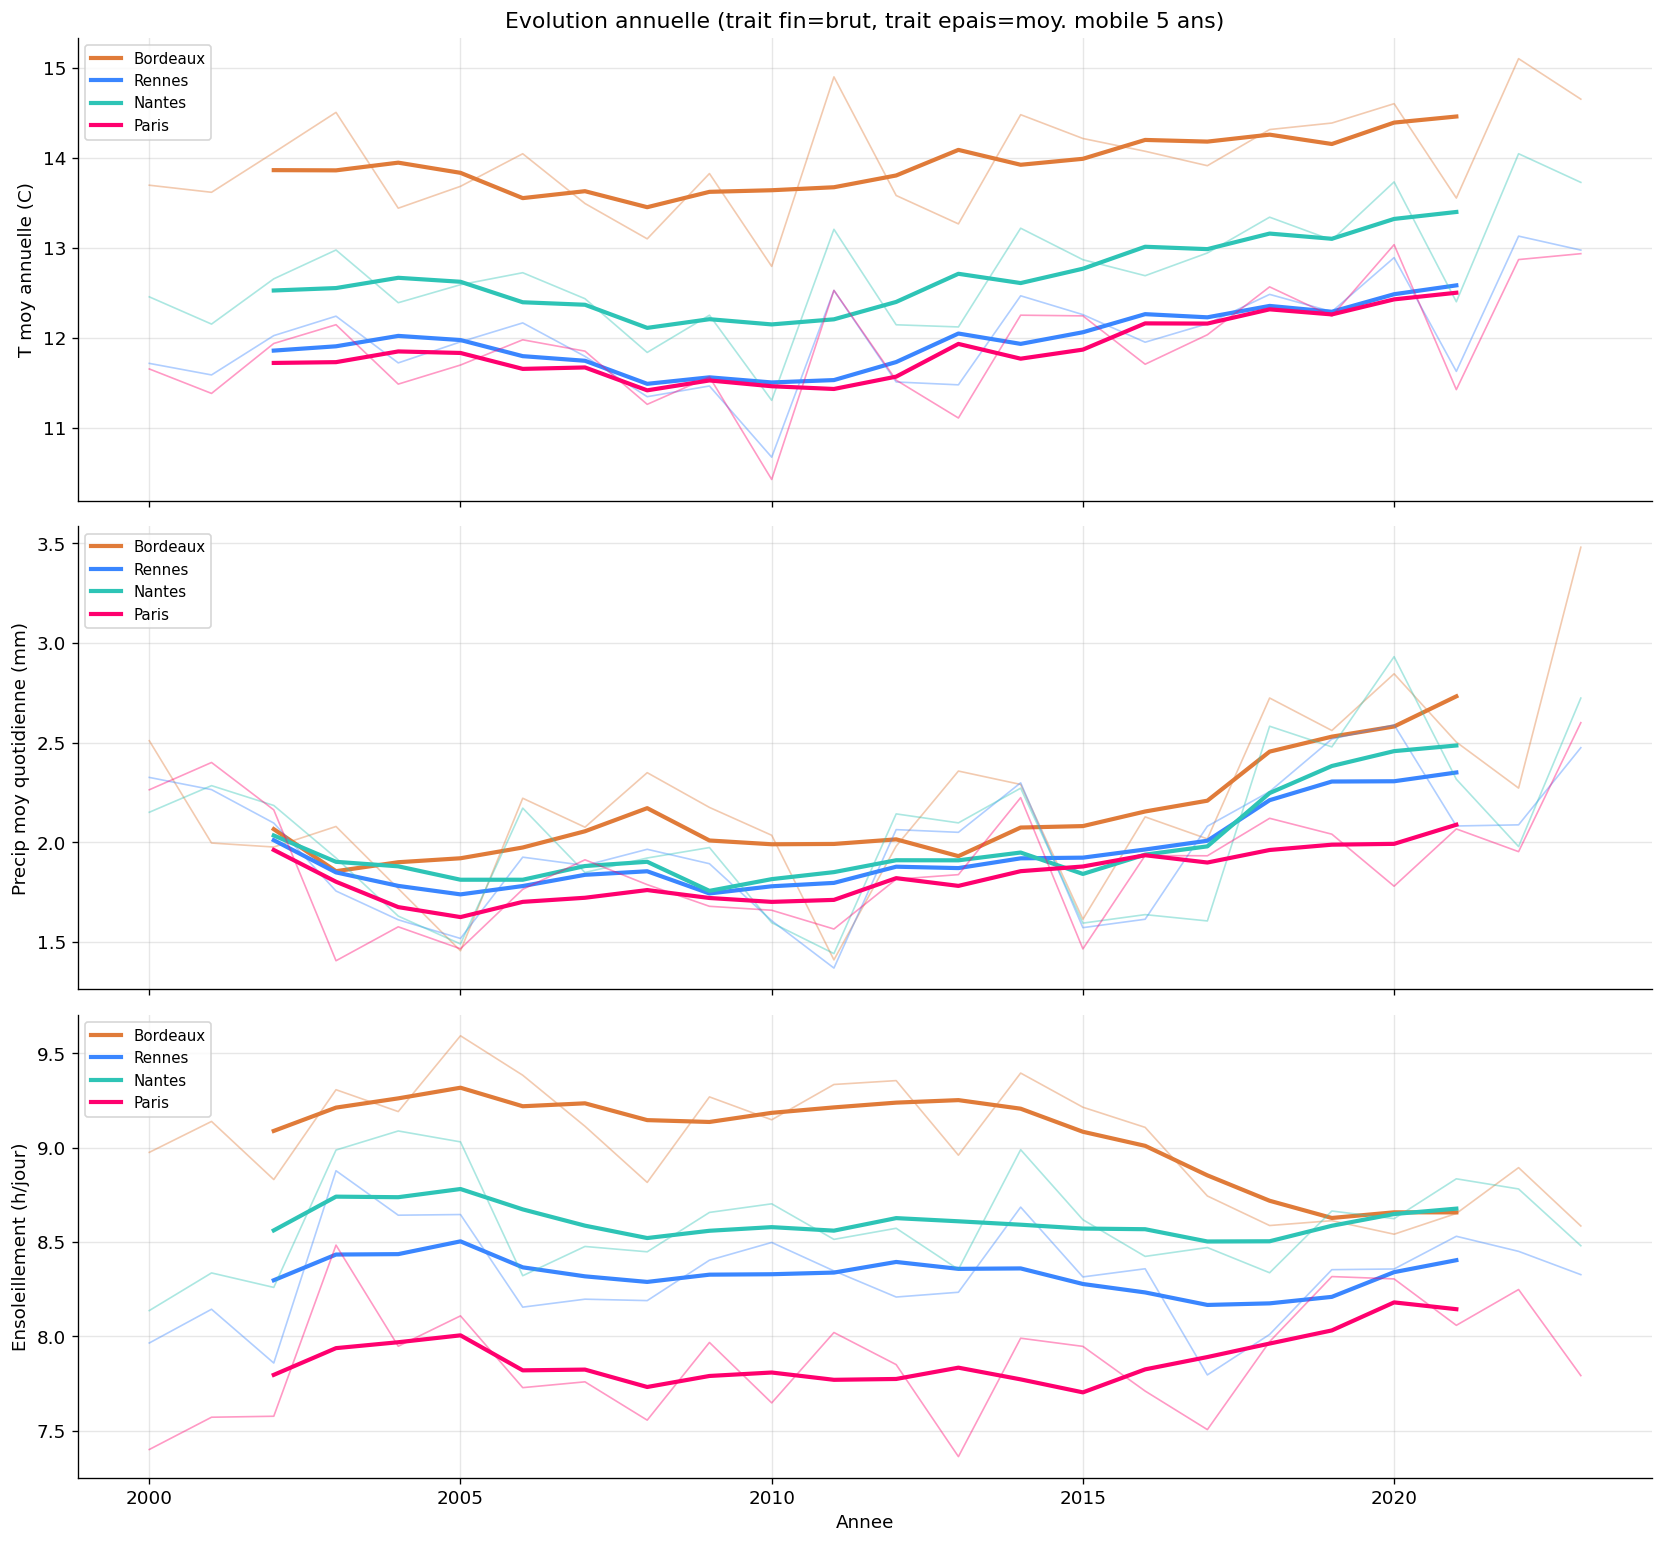

In [11]:
annuel = df.groupby(['ville','ANNEE'])[['TX','TN','TM','RR','ensoleillement_h','vent_max_kmh']].mean().reset_index()

fig, axes = plt.subplots(3,1,figsize=(14,13),sharex=True)
for ax, var, ylabel in zip(axes,['TM','RR','ensoleillement_h'],
    ['T moy annuelle (C)','Precip moy quotidienne (mm)','Ensoleillement (h/jour)']):
    for ville in VILLES:
        sub = annuel[annuel['ville']==ville].sort_values('ANNEE')
        ax.plot(sub['ANNEE'], sub[var], alpha=0.4, color=COLORS[ville], lw=1)
        ax.plot(sub['ANNEE'], sub[var].rolling(5,center=True).mean(),
                color=COLORS[ville], lw=2.5, label=ville)
    ax.set_ylabel(ylabel); ax.legend(loc='upper left', fontsize=9)
axes[0].set_title('Evolution annuelle (trait fin=brut, trait epais=moy. mobile 5 ans)')
axes[-1].set_xlabel('Annee')
plt.tight_layout(); plt.show()

In [12]:
resultats = []
for ville in VILLES:
    for var in ['TM','TX','TN','RR','ensoleillement_h']:
        d = annuel[annuel['ville']==ville][['ANNEE',var]].dropna()
        if len(d) < 5: continue
        slope, _, r, p, _ = stats.linregress(d['ANNEE'], d[var])
        resultats.append({'Ville':ville,'Variable':var,'Tendance/10ans':round(slope*10,3),
                          'R2':round(r**2,3),'p-value':round(p,4),'Significatif':'OK' if p<0.05 else '-'})
df_tend = pd.DataFrame(resultats)
print('=== TENDANCES LINEAIRES (/10 ans) ==='); df_tend

=== TENDANCES LINEAIRES (/10 ans) ===


,Ville,Variable,Tendance/10ans,R2,p-value,Significatif
0,Bordeaux,TM,0.359,0.192,0.0321,OK
1,Bordeaux,TX,0.453,0.206,0.0261,OK
2,Bordeaux,TN,0.339,0.196,0.0303,OK
3,Bordeaux,RR,0.325,0.261,0.0108,OK
4,Bordeaux,ensoleillement_h,-0.245,0.323,0.0038,OK
5,Rennes,TM,0.410,0.258,0.0113,OK
6,Rennes,TX,0.646,0.384,0.0012,OK
7,Rennes,TN,0.207,0.086,0.1644,-
8,Rennes,RR,0.163,0.118,0.0999,-
9,Rennes,ensoleillement_h,0.021,0.003,0.7875,-


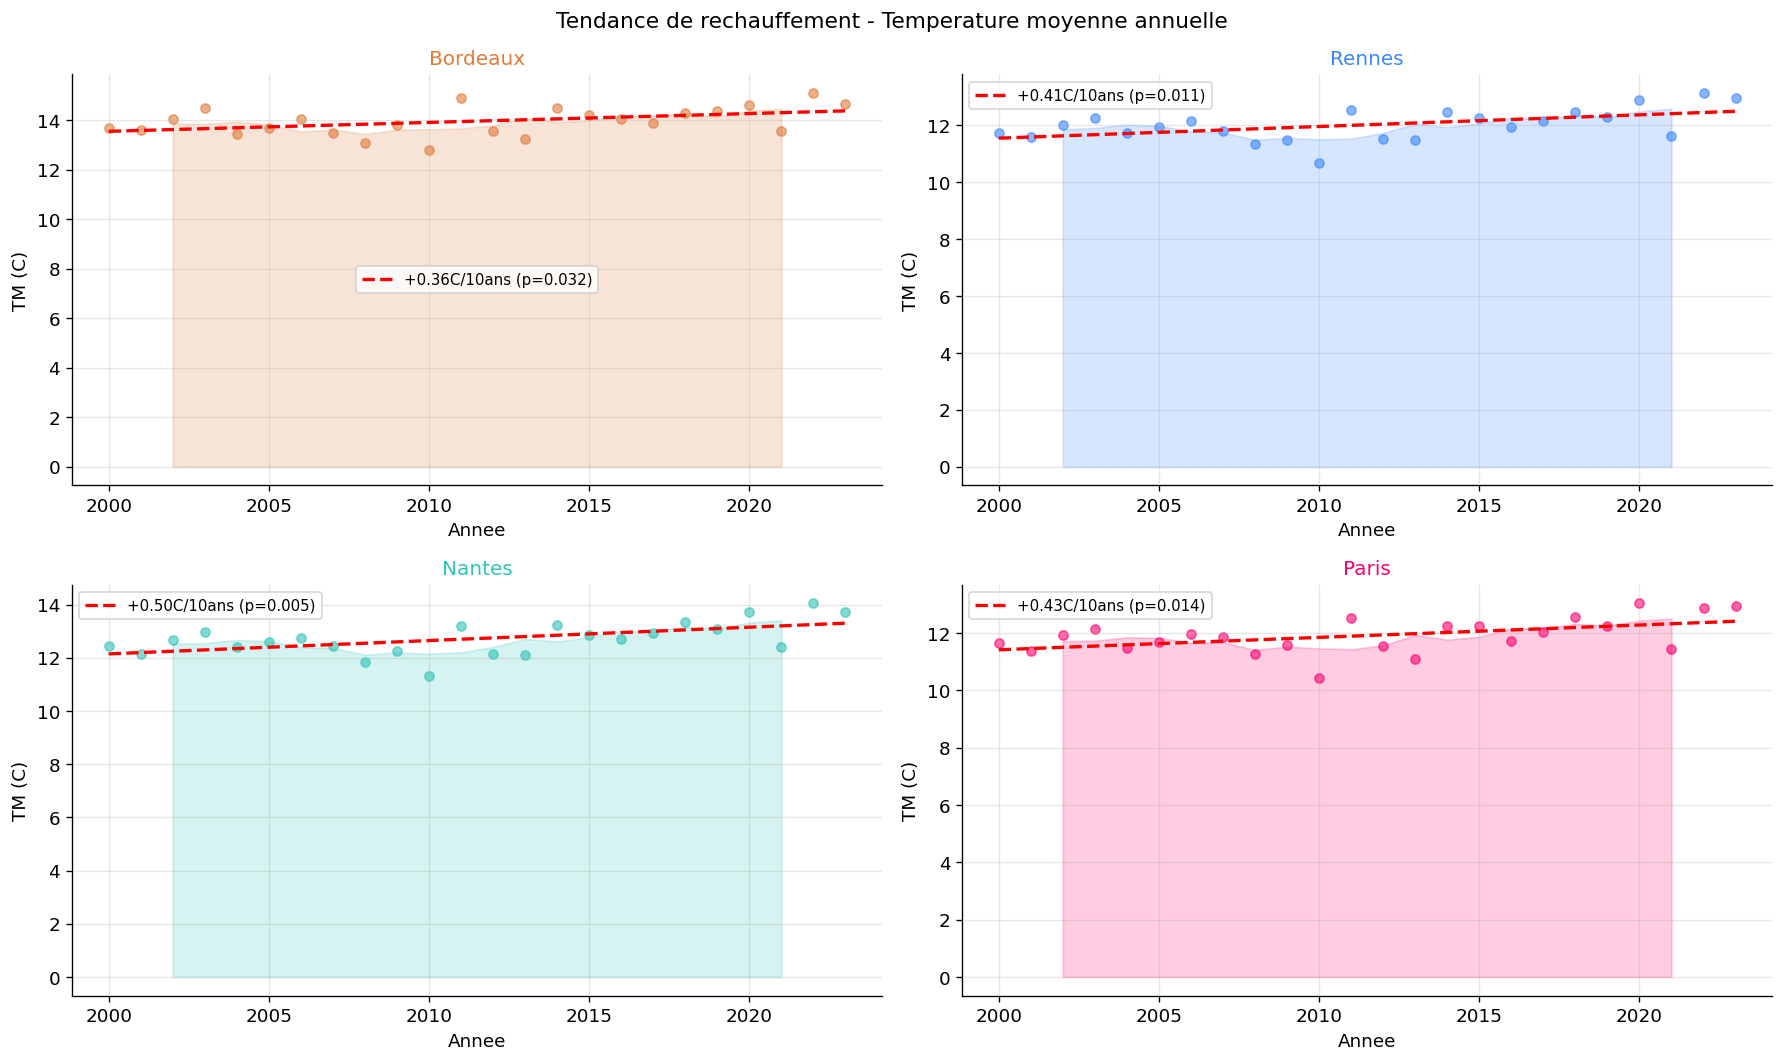

In [13]:
fig, axes = plt.subplots(2,2,figsize=(15,9))
for ax, ville in zip(axes.flatten(), VILLES):
    sub = annuel[annuel['ville']==ville][['ANNEE','TM']].dropna()
    color = COLORS[ville]
    ax.scatter(sub['ANNEE'], sub['TM'], color=color, alpha=0.6, s=30)
    slope, intercept, r, p, _ = stats.linregress(sub['ANNEE'], sub['TM'])
    x = np.array([sub['ANNEE'].min(), sub['ANNEE'].max()])
    ax.plot(x, slope*x+intercept, 'r--', lw=2, label=f'+{slope*10:.2f}C/10ans (p={p:.3f})')
    ax.fill_between(sub['ANNEE'], sub['TM'].rolling(5,center=True).mean(),
                    alpha=0.2, color=color)
    ax.set_title(ville, color=color, fontsize=12)
    ax.set_xlabel('Annee'); ax.set_ylabel('TM (C)'); ax.legend(fontsize=9)
fig.suptitle('Tendance de rechauffement - Temperature moyenne annuelle', fontsize=13)
plt.tight_layout(); plt.show()

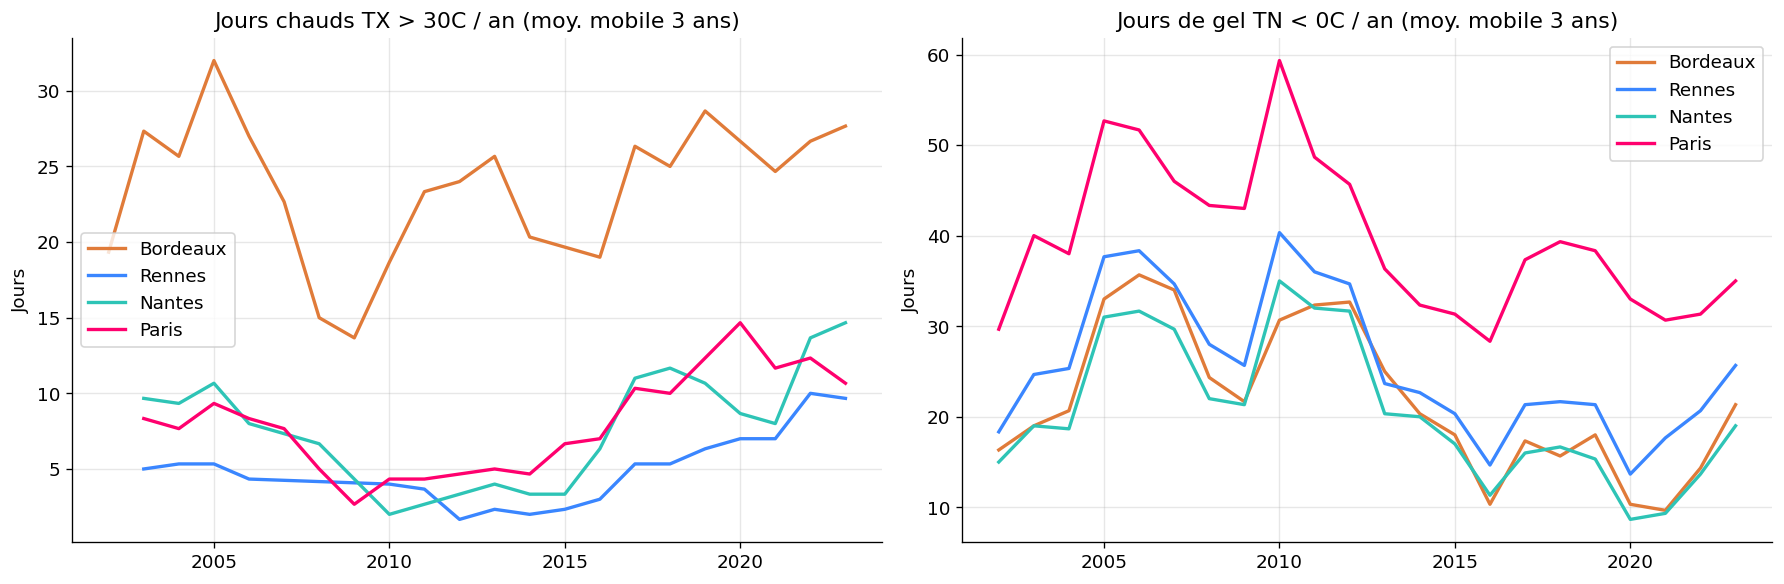

In [14]:
j_chauds = df[df['TX']>30].groupby(['ville','ANNEE']).size().reset_index(name='jours_chauds')
j_gel    = df[df['TN']<0 ].groupby(['ville','ANNEE']).size().reset_index(name='jours_gel')

fig, axes = plt.subplots(1,2,figsize=(15,5))
for ville in VILLES:
    sub  = j_chauds[j_chauds['ville']==ville]
    sub2 = j_gel[j_gel['ville']==ville]
    axes[0].plot(sub['ANNEE'],  sub['jours_chauds'].rolling(3).mean(), color=COLORS[ville], lw=2, label=ville)
    axes[1].plot(sub2['ANNEE'], sub2['jours_gel'].rolling(3).mean(),   color=COLORS[ville], lw=2, label=ville)
axes[0].set_title('Jours chauds TX > 30C / an (moy. mobile 3 ans)'); axes[0].set_ylabel('Jours'); axes[0].legend()
axes[1].set_title('Jours de gel TN < 0C / an (moy. mobile 3 ans)');  axes[1].set_ylabel('Jours'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 7. Anomalies climatiques <a id='7'></a>

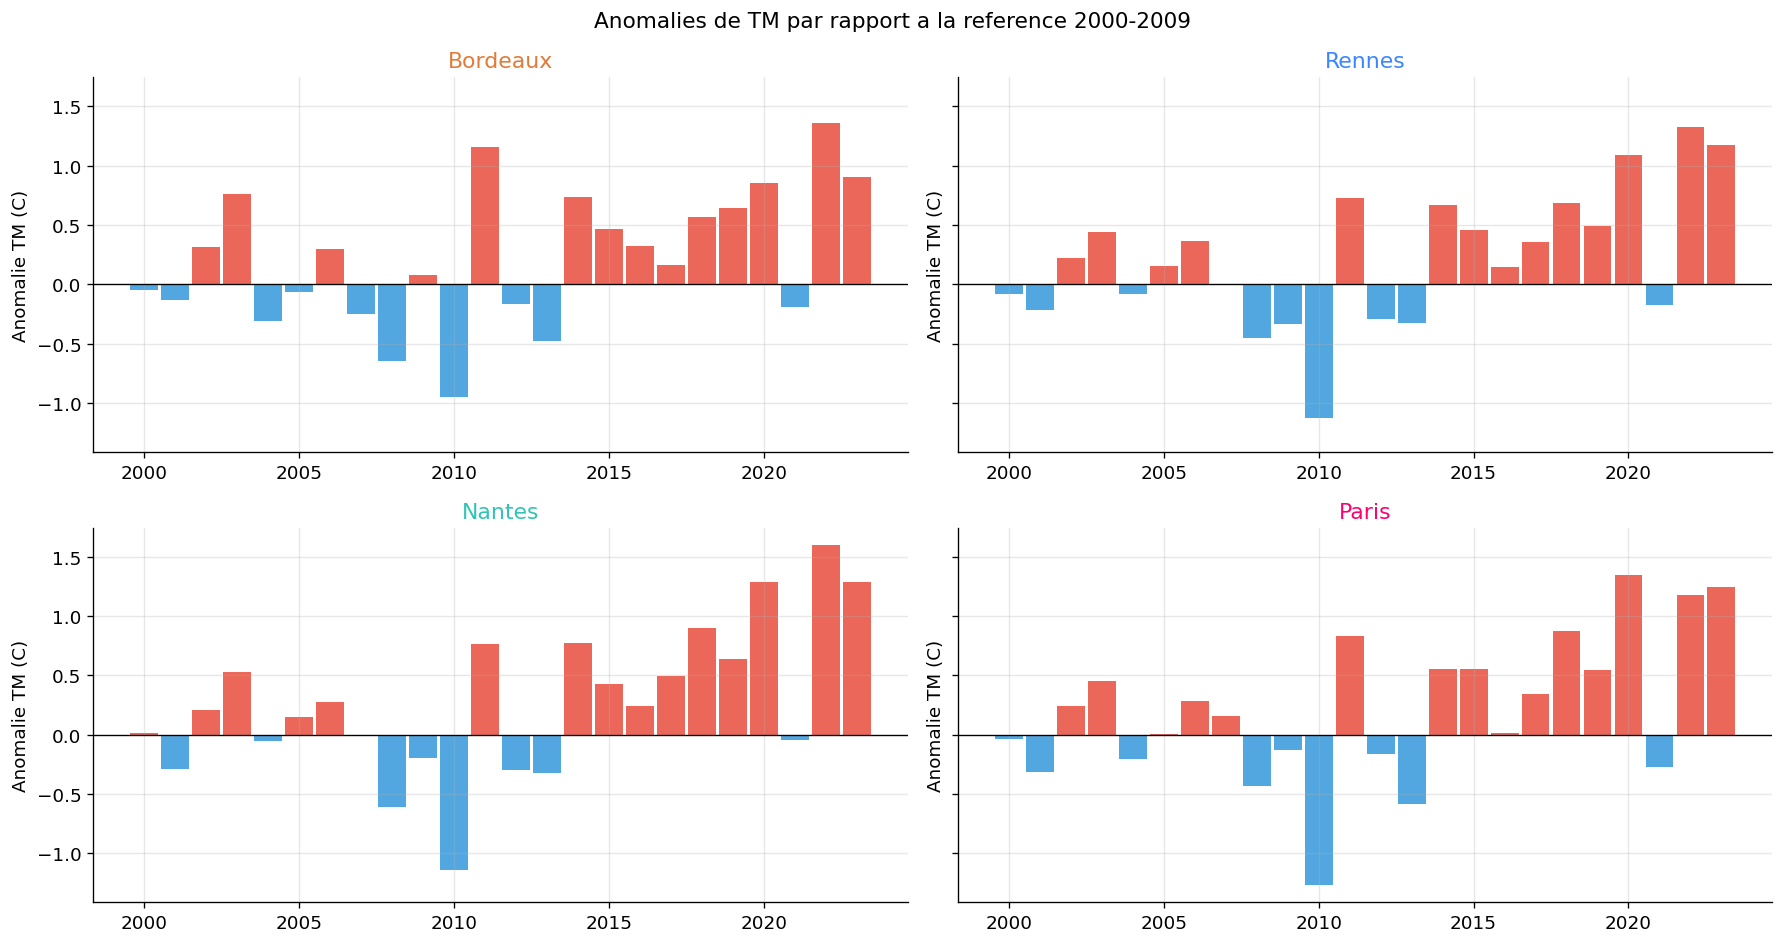

In [15]:
ref = df[df['ANNEE'].between(2000,2009)].groupby('ville')['TM'].mean().rename('ref')
annuel_a = annuel.join(ref, on='ville')
annuel_a['anomalie'] = annuel_a['TM'] - annuel_a['ref']

fig, axes = plt.subplots(2,2,figsize=(15,8),sharey=True)
for ax, ville in zip(axes.flatten(), VILLES):
    sub = annuel_a[annuel_a['ville']==ville].sort_values('ANNEE')
    couleurs = ['#e74c3c' if v>=0 else '#3498db' for v in sub['anomalie']]
    ax.bar(sub['ANNEE'], sub['anomalie'], color=couleurs, alpha=0.85, width=0.9)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(ville, color=COLORS[ville]); ax.set_ylabel('Anomalie TM (C)')
fig.suptitle('Anomalies de TM par rapport a la reference 2000-2009', fontsize=13)
plt.tight_layout(); plt.show()

---
## 8. Evenements extremes <a id='8'></a>

In [16]:
records = []
for ville in VILLES:
    sub = df[df['ville']==ville]
    for var, label, func in [('TX','TX max','max'),('TN','TN min','min'),
                              ('RR','RR max','max'),('vent_max_kmh','Vent max','max')]:
        val = getattr(sub[var], func)()
        date_rec = sub.loc[sub[var]==val,'DATE'].iloc[0].date() if not pd.isna(val) else '?'
        records.append({'Ville':ville,'Variable':label,'Valeur':round(val,1),'Date':str(date_rec)})
pd.DataFrame(records).pivot(index='Ville', columns='Variable', values=['Valeur','Date'])

Valeur                               Date                          \
Variable RR max TN min TX max Vent max      RR max      TN min      TX max   
Ville                                                                        
Bordeaux   51.4   -8.2   40.5     53.7  2013-06-18  2007-01-26  2022-06-18   
Nantes     66.9   -7.0   40.1     59.0  2021-10-02  2003-01-09  2022-07-18   
Paris      33.5  -10.2   40.7     52.4  2002-06-05  2009-01-07  2019-07-25   
Rennes     37.7   -7.5   39.7     57.3  2010-11-13  2003-01-09  2022-07-18   

                      
Variable    Vent max  
Ville                 
Bordeaux  2009-01-24  
Nantes    2017-03-06  
Paris     2021-10-21  
Rennes    2020-10-02

In [17]:
SEUIL = 35
vagues = []
for ville in VILLES:
    sub = df[df['ville']==ville].sort_values('DATE').reset_index(drop=True)
    chaud = sub['TX'] >= SEUIL
    groupes = (chaud != chaud.shift()).cumsum()
    for g, grp in sub[chaud].groupby(groupes[chaud]):
        if len(grp) >= 3:
            vagues.append({'Ville':ville,'Debut':grp['DATE'].min().date(),
                           'Fin':grp['DATE'].max().date(),'Duree (j)':len(grp),
                           'TX max (C)':grp['TX'].max(),'TX moy (C)':round(grp['TX'].mean(),1)})
df_vagues = pd.DataFrame(vagues).sort_values('TX max (C)', ascending=False)
print(f'{len(df_vagues)} vagues de chaleur (TX >= {SEUIL}C, >= 3 jours consecutifs)')
df_vagues.head(15)

11 vagues de chaleur (TX >= 35C, >= 3 jours consecutifs)


,Ville,Debut,Fin,Duree (j),TX max (C),TX moy (C)
9,Paris,2019-07-23,2019-07-25,3,40.7,37.9
0,Bordeaux,2003-08-03,2003-08-05,3,40.2,38.7
4,Bordeaux,2019-07-22,2019-07-25,4,39.9,37.9
1,Bordeaux,2003-08-07,2003-08-13,7,39.5,37.5
5,Bordeaux,2022-07-16,2022-07-18,3,38.3,36.6
8,Paris,2003-08-05,2003-08-12,8,38.1,36.7
3,Bordeaux,2017-06-19,2017-06-21,3,38.0,37.0
6,Bordeaux,2022-08-09,2022-08-12,4,37.7,36.2
10,Paris,2020-08-07,2020-08-09,3,37.5,36.4
7,Nantes,2003-08-08,2003-08-10,3,36.9,36.4


Seuil P99 precipitations : 18.9 mm


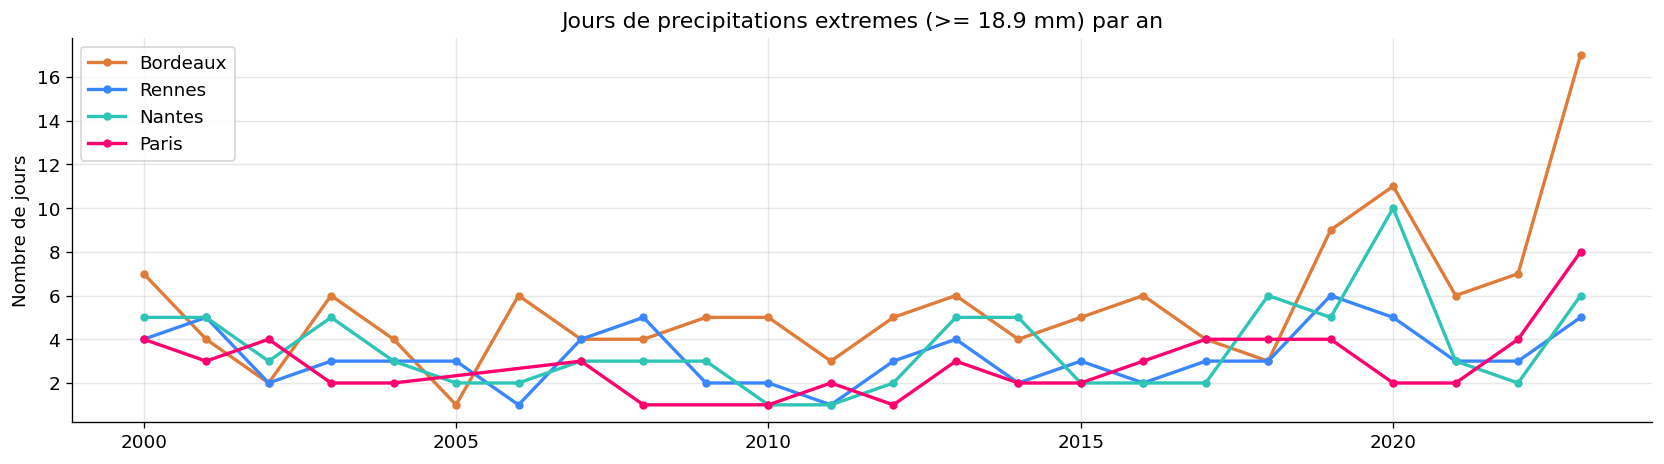

In [18]:
seuil_99 = df['RR'].quantile(0.99)
print(f'Seuil P99 precipitations : {seuil_99:.1f} mm')
extr_rr = df[df['RR']>=seuil_99].copy()
freq_rr = extr_rr.groupby(['ville','ANNEE']).size().reset_index(name='nb')

fig, ax = plt.subplots(figsize=(14,4))
for ville in VILLES:
    sub = freq_rr[freq_rr['ville']==ville]
    ax.plot(sub['ANNEE'], sub['nb'], color=COLORS[ville], lw=2, marker='o', ms=4, label=ville)
ax.set_title(f'Jours de precipitations extremes (>= {seuil_99:.1f} mm) par an')
ax.set_ylabel('Nombre de jours'); ax.legend()
plt.tight_layout(); plt.show()

---
## 9. Correlations entre variables <a id='9'></a>

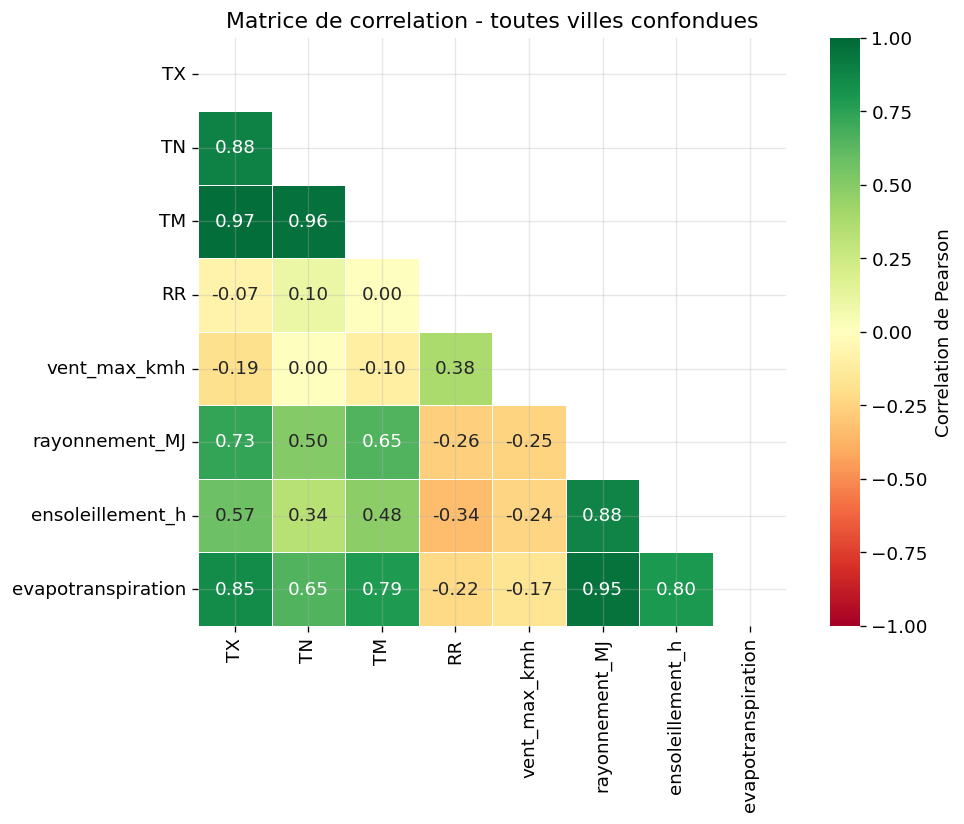

In [19]:
vars_corr = ['TX','TN','TM','RR','vent_max_kmh','rayonnement_MJ','ensoleillement_h','evapotranspiration']
corr = df[vars_corr].corr()
fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label':'Correlation de Pearson'})
ax.set_title('Matrice de correlation - toutes villes confondues')
plt.tight_layout(); plt.show()

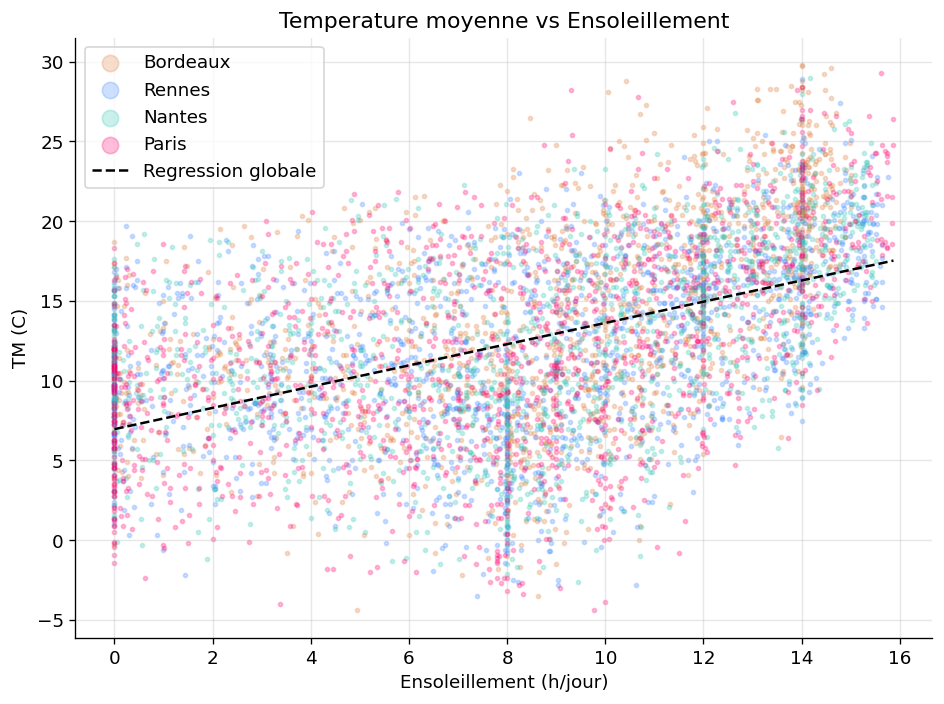

In [20]:
fig, ax = plt.subplots(figsize=(8,6))
sample = df.dropna(subset=['TM','ensoleillement_h']).sample(min(6000,len(df)), random_state=42)
for ville in VILLES:
    sub = sample[sample['ville']==ville]
    ax.scatter(sub['ensoleillement_h'], sub['TM'], color=COLORS[ville], alpha=0.25, s=6, label=ville)
slope, intercept, *_ = stats.linregress(sample['ensoleillement_h'], sample['TM'])
x_r = np.linspace(0, sample['ensoleillement_h'].max(), 100)
ax.plot(x_r, slope*x_r+intercept, 'k--', lw=1.5, label='Regression globale')
ax.set_xlabel('Ensoleillement (h/jour)'); ax.set_ylabel('TM (C)')
ax.set_title('Temperature moyenne vs Ensoleillement')
ax.legend(markerscale=4)
plt.tight_layout(); plt.show()

---
## 10. Comparaison inter-villes <a id='10'></a>

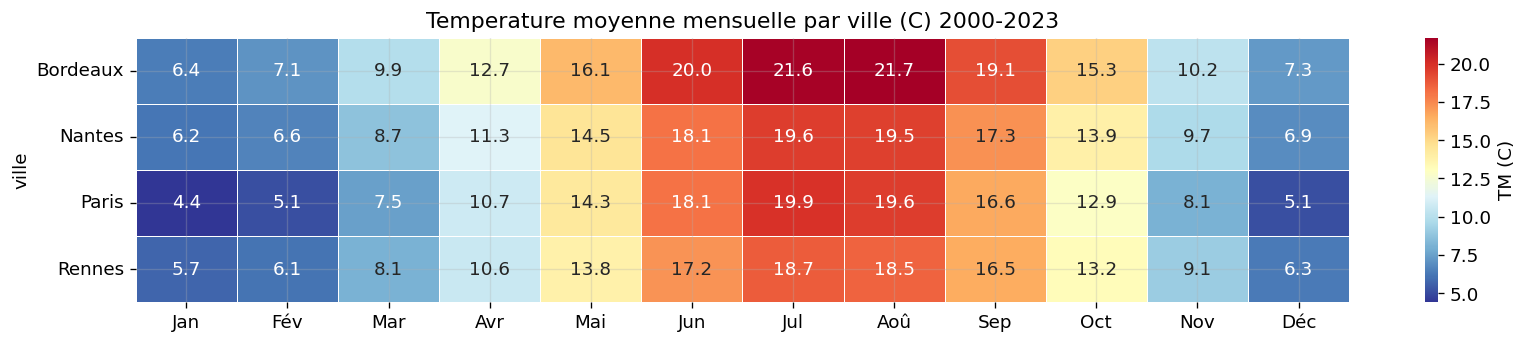

In [21]:
pivot_tm = df.groupby(['ville','MOIS'])['TM'].mean().unstack('MOIS').round(1)
pivot_tm.columns = MOIS_FR
fig, ax = plt.subplots(figsize=(14,3))
sns.heatmap(pivot_tm, ax=ax, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.5, cbar_kws={'label':'TM (C)'})
ax.set_title('Temperature moyenne mensuelle par ville (C) 2000-2023')
plt.tight_layout(); plt.show()

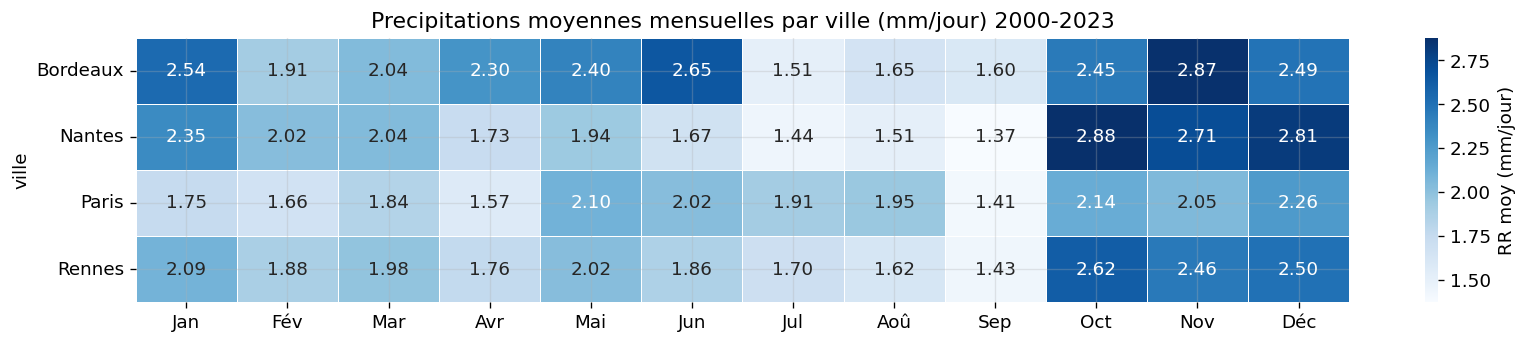

In [22]:
pivot_rr = df.groupby(['ville','MOIS'])['RR'].mean().unstack('MOIS').round(2)
pivot_rr.columns = MOIS_FR
fig, ax = plt.subplots(figsize=(14,3))
sns.heatmap(pivot_rr, ax=ax, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label':'RR moy (mm/jour)'})
ax.set_title('Precipitations moyennes mensuelles par ville (mm/jour) 2000-2023')
plt.tight_layout(); plt.show()

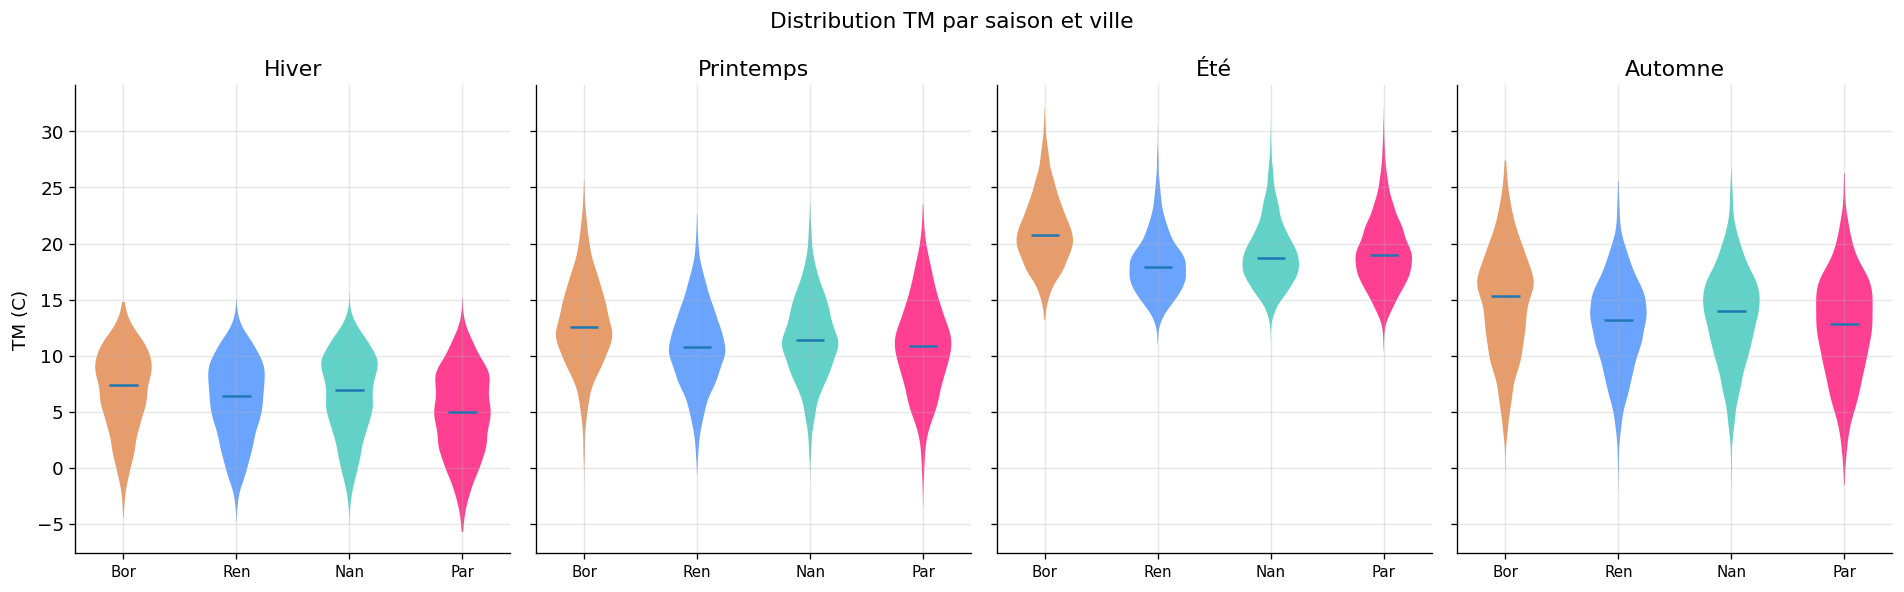

In [23]:
fig, axes = plt.subplots(1,4,figsize=(16,5),sharey=True)
for ax, saison in zip(axes, ['Hiver','Printemps','Ete','Automne']):
    saison_key = 'Été' if saison == 'Ete' else saison
    sub = df[df['SAISON']==saison_key]
    data_v = [sub.loc[sub['ville']==v,'TM'].dropna().values for v in VILLES]
    parts = ax.violinplot(data_v, showmedians=True, showextrema=False)
    for pc, ville in zip(parts['bodies'], VILLES):
        pc.set_facecolor(COLORS[ville]); pc.set_alpha(0.75)
    ax.set_xticks(range(1,5))
    ax.set_xticklabels([v[:3] for v in VILLES], fontsize=9)
    ax.set_title(saison_key)
axes[0].set_ylabel('TM (C)')
fig.suptitle('Distribution TM par saison et ville', fontsize=13)
plt.tight_layout(); plt.show()

---
## 11. Synthese <a id='11'></a>

In [24]:
synthese = []
for ville in VILLES:
    sub = df[df['ville']==ville]
    ann = annuel[annuel['ville']==ville][['ANNEE','TM']].dropna()
    slope, _, _, p, _ = stats.linregress(ann['ANNEE'], ann['TM'])
    synthese.append({
        'Ville':             ville,
        'TM moy (C)':        round(sub['TM'].mean(),2),
        'TX moy (C)':        round(sub['TX'].mean(),2),
        'TN moy (C)':        round(sub['TN'].mean(),2),
        'RR moy (mm/j)':     round(sub['RR'].mean(),2),
        'Vent moy (km/h)':   round(sub['vent_max_kmh'].mean(),1),
        'Soleil moy (h/j)':  round(sub['ensoleillement_h'].mean(),2),
        'Tendance /10ans':   f"{slope*10:+.2f}C{'*' if p<0.05 else ''}",
        'Jours TX>30/an':    round(df[(df['ville']==ville)&(df['TX']>30)].groupby('ANNEE').size().mean(),1),
        'Jours TN<0/an':     round(df[(df['ville']==ville)&(df['TN']<0)].groupby('ANNEE').size().mean(),1),
    })

df_synth = pd.DataFrame(synthese).set_index('Ville')
print('=== TABLEAU DE SYNTHESE (* = tendance significative p<0.05) ===')
df_synth

=== TABLEAU DE SYNTHESE (* = tendance significative p<0.05) ===


,TM moy (C),TX moy (C),TN moy (C),RR moy (mm/j),Vent moy (km/h),Soleil moy (h/j),Tendance /10ans,Jours TX>30/an,Jours TN<0/an
Ville,,,,,,,,,
Bordeaux,13.97,18.58,9.75,2.20,15.6,9.03,+0.36C*,23.8,21.9
Rennes,12.02,15.90,8.30,2.00,18.9,8.31,+0.41C*,5.2,25.4
Nantes,12.72,16.46,9.19,2.04,19.9,8.59,+0.50C*,8.0,20.5
Paris,11.91,15.87,7.95,1.89,18.4,7.87,+0.43C*,8.1,39.0
